In [229]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [ ]:
# %pip install scipy pandas


In [ ]:
# %pip install --upgrade --force-reinstall numpy scipy scikit-learn

In [ ]:
# %pip install scikit-learn

In [230]:
from scipy.io import arff

# 1. Load the ARFF file using SciPy
data, meta = arff.loadarff("C:/Users/USUARIO/Documents/Codigos/Proyecto e-commerce/data/data.arff")

# 2. Convert it into a Pandas DataFrame
df = pd.DataFrame(data)

df.head()

,customer_state,total_payment_value,total_freight,total_weight_g,total_volume_cm3,principal_category_by_price,principal_seller_state_by_price,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,...,dias_entrega_promedio_7d_avg,dias_entrega_promedio_t2,dias_entrega_promedio_prev_month,es_post_domingo_festivo,es_diciembre,es_fin_de_semana_extendido,distancia_km,distancia_total_t1,distancia_total_prev_month,delivery_days
0,b'SP',38.71,8.72,500.0,1976.0,b'utilidades_domesticas',b'SP',2017.0,111.890769,91.660,...,10.860524,10.043478,11.886244,1.0,0.0,0.0,18.576110,4025.883311,291113.407386,8.0
1,b'SP',32.70,12.80,200.0,2560.0,b'cama_mesa_banho',b'SP',2018.0,169.101283,112.680,...,7.619223,9.063401,11.552505,0.0,0.0,0.0,309.131371,25226.900324,488209.852444,4.0
2,b'SP',54.36,16.11,583.0,8400.0,b'brinquedos',b'SP',2018.0,146.652034,100.230,...,14.771980,15.841772,14.586934,0.0,0.0,0.0,430.144201,21694.682189,421109.470293,11.0
3,b'SP',29.75,11.85,250.0,4800.0,b'cama_mesa_banho',b'SP',2017.0,170.919272,117.600,...,12.902686,12.000000,11.846389,0.0,0.0,0.0,209.757656,9623.066166,343516.704227,6.0
4,b'SP',118.86,8.96,525.0,4368.0,b'beleza_saude',b'SP',2017.0,219.488889,106.805,...,11.561738,10.369565,11.021440,1.0,0.0,0.0,11.680956,6110.978959,304388.330097,21.0


In [233]:
#Correccion de tipos de datos
df['customer_state']=df['customer_state'].astype('category')
df["principal_category_by_price"] = df["principal_category_by_price"].astype('category')
df["principal_seller_state_by_price"] = df["principal_seller_state_by_price"].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24916 entries, 0 to 24915
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   customer_state                    24916 non-null  category
 1   total_payment_value               24916 non-null  float64 
 2   total_freight                     24916 non-null  float64 
 3   total_weight_g                    24916 non-null  float64 
 4   total_volume_cm3                  24916 non-null  float64 
 5   principal_category_by_price       24916 non-null  category
 6   principal_seller_state_by_price   24916 non-null  category
 7   purchase_year                     24916 non-null  float64 
 8   facturacion_promedio_t1           24916 non-null  float64 
 9   facturacion_mediana_t1            24916 non-null  float64 
 10  facturacion_std_t1                24916 non-null  float64 
 11  facturacion_total_7d_avg          24916 non-null  floa

In [232]:
umbral = df["distancia_km"].quantile(0.985)
df = df[df["distancia_km"] <= umbral].reset_index(drop=True)

df = df[df["distancia_km"] > 4].reset_index(drop=True)

<Axes: >

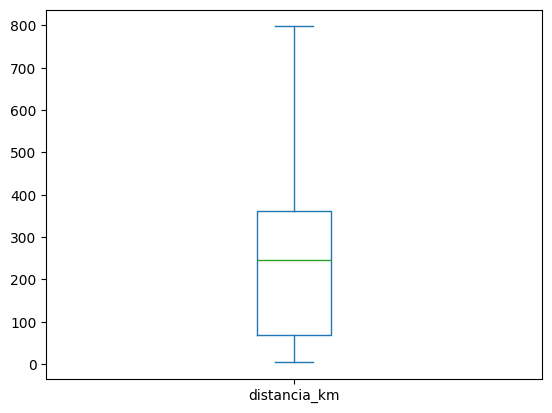

In [234]:
df["distancia_km"].plot(kind='box')


<Axes: >

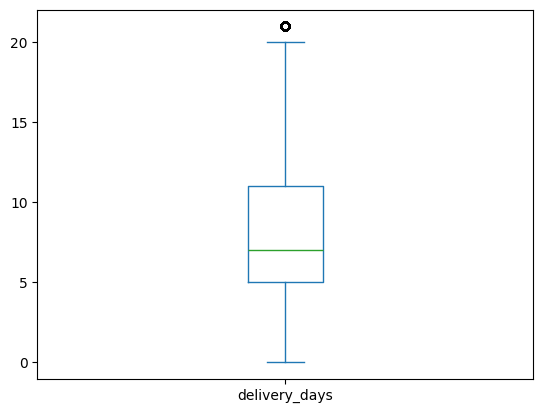

In [53]:
# df = df[df["delivery_days"] > 0].reset_index(drop=True)
df = df[df["delivery_days"] < 22].reset_index(drop=True)


df["delivery_days"].plot(kind='box')


<Axes: >

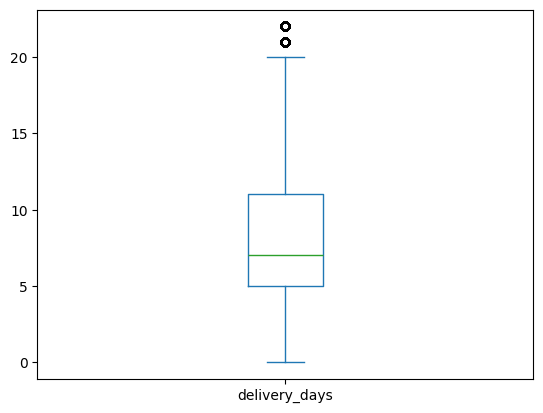

In [235]:
df["delivery_days"].plot(kind='box')


In [210]:
df = df[df["delivery_days"] < 18].reset_index(drop=True)


In [236]:
umbral = df["total_volume_cm3"].quantile(0.95)
df = df[df["total_volume_cm3"] <= umbral].reset_index(drop=True)

print(df.shape)   # esperado: ~24.240 filas (se eliminan ~1.276)

(23683, 22)


<Axes: >

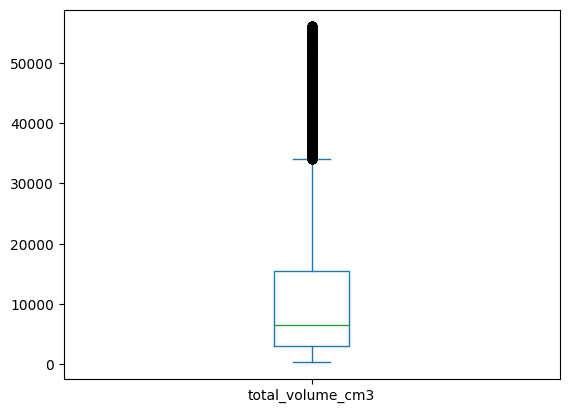

In [237]:
df["total_volume_cm3"].plot(kind='box')



In [238]:
umbral = df["total_weight_g"].quantile(0.95)
df = df[df["total_weight_g"] <= umbral].reset_index(drop=True)

<Axes: >

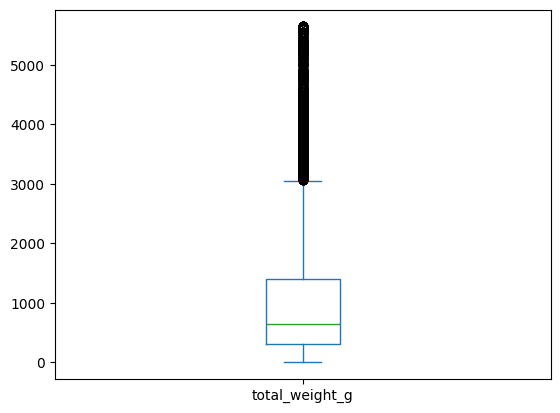

In [58]:
df["total_weight_g"].plot(kind='box')


In [239]:
umbral = df["total_freight"].quantile(0.95)
df = df[df["total_freight"] <= umbral].reset_index(drop=True)
print((df["total_freight"] == 0).sum())   # cuántos registros tienen flete 0

df = df[df["total_freight"] != 0].reset_index(drop=True)
print(df.shape)

123
(21251, 22)


<Axes: >

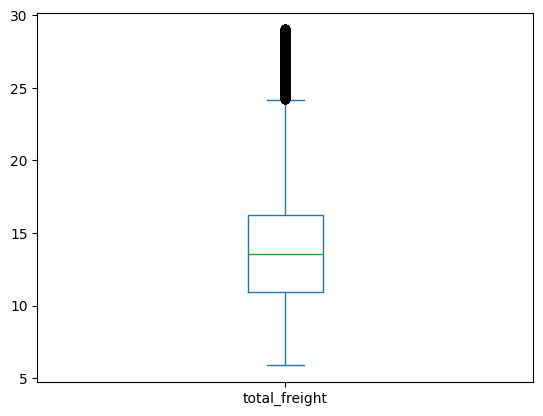

In [60]:
df["total_freight"].plot(kind='box')


0


<Axes: >

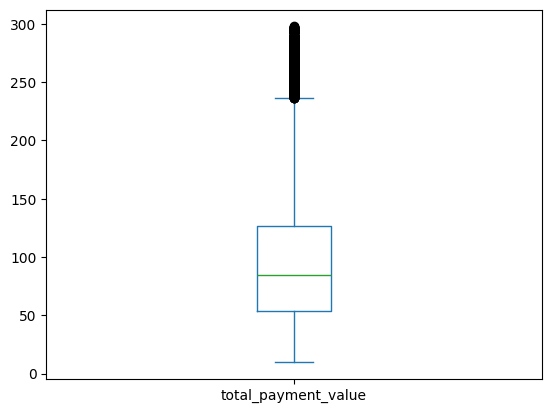

In [240]:
umbral = df["total_payment_value"].quantile(0.95)
df = df[df["total_payment_value"] <= umbral].reset_index(drop=True)
print((df["total_payment_value"] == 0).sum())   # cuántos registros tienen flete 0

df = df[df["total_payment_value"] != 0].reset_index(drop=True)

df["total_payment_value"].plot(kind='box')

<Axes: >

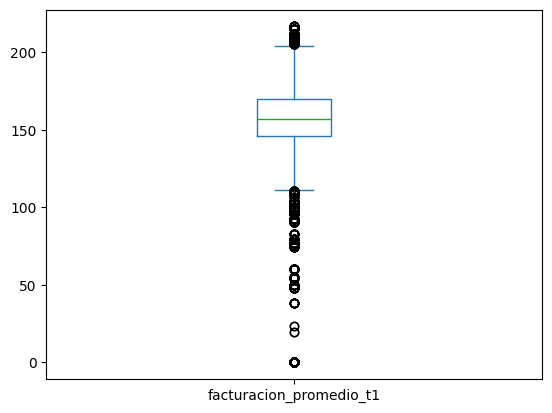

In [241]:
umbral = df["facturacion_promedio_t1"].quantile(0.95)
df = df[df["facturacion_promedio_t1"] <= umbral].reset_index(drop=True)

df["facturacion_promedio_t1"].plot(kind='box')

array([[<Axes: title={'center': 'total_payment_value'}>,
        <Axes: title={'center': 'total_freight'}>,
        <Axes: title={'center': 'total_weight_g'}>,
        <Axes: title={'center': 'total_volume_cm3'}>],
       [<Axes: title={'center': 'purchase_year'}>,
        <Axes: title={'center': 'facturacion_promedio_t1'}>,
        <Axes: title={'center': 'facturacion_mediana_t1'}>,
        <Axes: title={'center': 'facturacion_std_t1'}>],
       [<Axes: title={'center': 'facturacion_total_7d_avg'}>,
        <Axes: title={'center': 'dias_entrega_promedio_7d_avg'}>,
        <Axes: title={'center': 'dias_entrega_promedio_t2'}>,
        <Axes: title={'center': 'dias_entrega_promedio_prev_month'}>],
       [<Axes: title={'center': 'es_post_domingo_festivo'}>,
        <Axes: title={'center': 'es_diciembre'}>,
        <Axes: title={'center': 'es_fin_de_semana_extendido'}>,
        <Axes: title={'center': 'distancia_km'}>],
       [<Axes: title={'center': 'distancia_total_t1'}>,
        <Axes

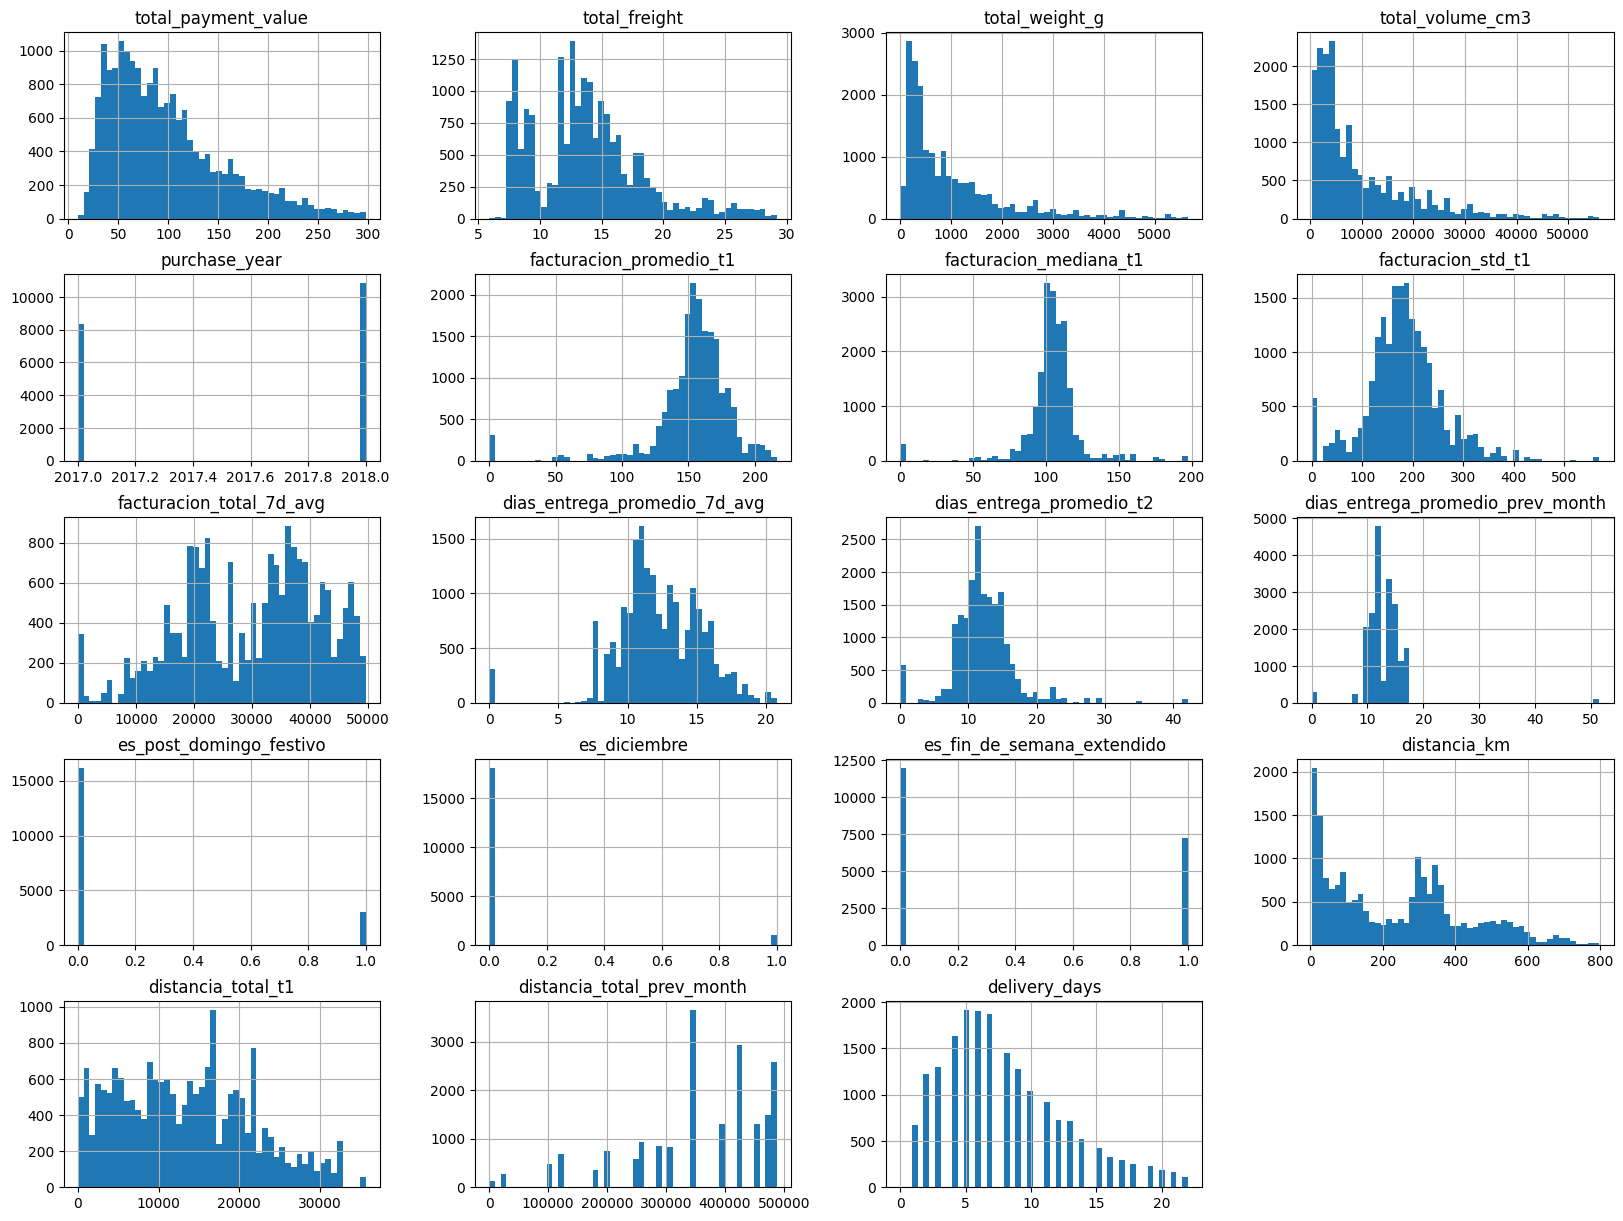

In [242]:
df.hist(bins=50, figsize=(20,15))

In [ ]:
# %pip install ydata-profiling

In [ ]:
# # Perfilado de datos
# from ydata_profiling import ProfileReport

# profile_data=ProfileReport(df, minimal=True) # minimal=False
# profile_data

In [9]:
print(df[cat_cols].isna().sum())
print(df[cat_cols].head())

customer_state                     0
principal_category_by_price        0
principal_seller_state_by_price    0
dtype: int64
  customer_state principal_category_by_price principal_seller_state_by_price
0             SP       utilidades_domesticas                              SP
1             SP             cama_mesa_banho                              SP
2             SP                  brinquedos                              SP
3             SP             cama_mesa_banho                              SP
4             SP                beleza_saude                              SP


In [243]:
df["purchase_year"] = df["purchase_year"].astype(int)
flags = ["es_post_domingo_festivo", "es_diciembre", "es_fin_de_semana_extendido"]
df[flags] = df[flags].astype(int)

cat_cols = ["customer_state", "principal_category_by_price", "principal_seller_state_by_price"]
for col in cat_cols:
    df[col] = (
        df[col].astype(object)
        .map(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)
        .astype("category")
    )

data = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
print(data.shape)
print([c for c in data.columns if "b'" in c])  # debe imprimir []
print(data.head())

(19187, 33)
[]
   total_payment_value  total_freight  total_weight_g  total_volume_cm3  \
0                38.71           8.72           500.0            1976.0   
1                32.70          12.80           200.0            2560.0   
2                54.36          16.11           583.0            8400.0   
3                29.75          11.85           250.0            4800.0   
4                88.90           8.91           250.0            3960.0   

   purchase_year  facturacion_promedio_t1  facturacion_mediana_t1  \
0           2017               111.890769                  91.660   
1           2018               169.101283                 112.680   
2           2018               146.652034                 100.230   
3           2017               170.919272                 117.600   
4           2018               138.861099                 100.485   

   facturacion_std_t1  facturacion_total_7d_avg  dias_entrega_promedio_7d_avg  \
0          107.145481              225

In [244]:
#Se separa variables predictoras y objetivo
objetivo = 'delivery_days'
X = data.drop(objetivo, axis=1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19187 entries, 0 to 19186
Data columns (total 32 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   total_payment_value                                 19187 non-null  float64
 1   total_freight                                       19187 non-null  float64
 2   total_weight_g                                      19187 non-null  float64
 3   total_volume_cm3                                    19187 non-null  float64
 4   purchase_year                                       19187 non-null  int64  
 5   facturacion_promedio_t1                             19187 non-null  float64
 6   facturacion_mediana_t1                              19187 non-null  float64
 7   facturacion_std_t1                                  19187 non-null  float64
 8   facturacion_total_7d_avg                            19187 non-null  float64


In [245]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate
from sklearn import tree

# 1. Creas la función
def wmape_func(y_real, y_pred):
    return np.sum(np.abs(y_real - y_pred)) / np.sum(np.abs(y_real))

# 2. La conviertes en un métrica compatible con Scikit-Learn
# Le ponemos greater_is_better=False para que siga la misma lógica negativa de tus otras métricas
wmape_scorer = make_scorer(wmape_func, greater_is_better=False)

# 3. Lo agregas a tu diccionario de métricas
scoring = {
    'neg_mean_absolute_error': 'neg_mean_absolute_error',
    'neg_mean_squared_error': 'neg_mean_squared_error',
    'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
    'neg_wmape': wmape_scorer, # <--- Tu nueva métrica
    # 'neg_mean_absolute_percentage_error':  'neg_mean_absolute_percentage_error'
}

cv = 10


In [246]:
#Tree
from sklearn import tree
from sklearn.model_selection import cross_validate

modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=22, max_depth=7, random_state=42)


scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# print(scores)


# 1. Conviertes el diccionario de resultados a un DataFrame
scores_df = pd.DataFrame(scores)

# 2. Ahora sí puedes calcular el promedio
resultados_promedio_dt = scores_df.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_dt[2:] = resultados_promedio_dt[2:].abs()

print(resultados_promedio_dt)

fit_time                              0.083962
score_time                            0.002920
test_neg_mean_absolute_error          2.960006
train_neg_mean_absolute_error         2.859148
test_neg_mean_squared_error          14.924589
train_neg_mean_squared_error         13.901270
test_neg_root_mean_squared_error      3.862860
train_neg_root_mean_squared_error     3.728412
test_neg_wmape                        0.373763
train_neg_wmape                       0.360954
dtype: float64


In [ ]:
# import pandas as pd

# # 1. Conviertes el diccionario de resultados a un DataFrame
# scores_df = pd.DataFrame(scores)

# # 2. Ahora sí puedes calcular el promedio
# resultados_promedio = scores_df.mean()

# # 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
# resultados_promedio[2:] = resultados_promedio[2:].abs()

# print(resultados_promedio)

In [258]:
#Random forest
from sklearn import ensemble
modelRf = ensemble.RandomForestRegressor(
    n_estimators=200, max_samples=0.9, criterion='squared_error', min_samples_leaf=8, max_depth=10, max_features=0.9, random_state=42, n_jobs=-1
)
scores = cross_validate(modelRf, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# print(scores)

# 1. Conviertes el diccionario de resultados a un DataFrame
scores_df = pd.DataFrame(scores)

# 2. Ahora sí puedes calcular el promedio
resultados_promedio_rf = scores_df.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_rf[2:] = resultados_promedio_rf[2:].abs()

print(resultados_promedio_rf)



fit_time                              1.159376
score_time                            0.052477
test_neg_mean_absolute_error          2.845195
train_neg_mean_absolute_error         2.533841
test_neg_mean_squared_error          13.812906
train_neg_mean_squared_error         10.985644
test_neg_root_mean_squared_error      3.716054
train_neg_root_mean_squared_error     3.314454
test_neg_wmape                        0.359273
train_neg_wmape                       0.319886
dtype: float64


In [ ]:
# 1. Conviertes el diccionario de resultados a un DataFrame
# scores_df = pd.DataFrame(scores)


# # 2. Ahora sí puedes calcular el promedio
# resultados_promedio = scores_df.mean()

# # 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
# resultados_promedio[2:] = resultados_promedio[2:].abs()

# print(resultados_promedio)

In [248]:
from sklearn.preprocessing import MinMaxScaler

# Solo las variables continuas (dummies y banderas ya están en 0/1)
variables_continuas = [
    'total_payment_value', 'total_freight', 'total_weight_g', 'total_volume_cm3',
    'purchase_year', 'facturacion_promedio_t1', 'facturacion_mediana_t1',
    'facturacion_std_t1', 'facturacion_total_7d_avg',
    'dias_entrega_promedio_7d_avg', 'dias_entrega_promedio_t2',
    'dias_entrega_promedio_prev_month', 'distancia_km',
    'distancia_total_t1', 'distancia_total_prev_month'
]

X_esc = X.copy()
X_esc[variables_continuas] = MinMaxScaler().fit_transform(X[variables_continuas])

X_esc.describe().loc[["min", "max"]]   # verificación: todo entre 0 y 1

,total_payment_value,total_freight,total_weight_g,total_volume_cm3,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,facturacion_std_t1,facturacion_total_7d_avg,dias_entrega_promedio_7d_avg,...,principal_category_by_price_cama_mesa_banho,principal_category_by_price_esporte_lazer,principal_category_by_price_informatica_acessorios,principal_category_by_price_moveis_decoracao,principal_category_by_price_relogios_presentes,principal_category_by_price_utilidades_domesticas,principal_seller_state_by_price_MG,principal_seller_state_by_price_PR,principal_seller_state_by_price_RJ,principal_seller_state_by_price_SP
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [153]:
X_esc.describe()   # verificación: todo entre 0 y 1

,total_payment_value,total_freight,total_weight_g,total_volume_cm3,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,facturacion_std_t1,facturacion_total_7d_avg,dias_entrega_promedio_7d_avg,...,principal_category_by_price_cama_mesa_banho,principal_category_by_price_esporte_lazer,principal_category_by_price_informatica_acessorios,principal_category_by_price_moveis_decoracao,principal_category_by_price_relogios_presentes,principal_category_by_price_utilidades_domesticas,principal_seller_state_by_price_MG,principal_seller_state_by_price_PR,principal_seller_state_by_price_RJ,principal_seller_state_by_price_SP
count,19052.000000,19052.000000,19052.000000,19052.000000,19052.00000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,...,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000,19052.000000
mean,0.305780,0.342449,0.175341,0.166165,0.56477,0.709441,0.528733,0.321562,0.603482,0.593371,...,0.200189,0.142347,0.109175,0.109017,0.096525,0.103821,0.058367,0.072696,0.050126,0.818812
std,0.199790,0.194487,0.179425,0.175219,0.49580,0.139552,0.104720,0.132764,0.236615,0.148603,...,0.400152,0.349415,0.311867,0.311669,0.295318,0.305036,0.234441,0.259643,0.218211,0.385184
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.153330,0.219344,0.051681,0.044390,0.00000,0.673360,0.501974,0.248800,0.417757,0.508151,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.260755,0.325777,0.106195,0.096346,1.00000,0.725204,0.533025,0.318203,0.648722,0.575515,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.406190,0.441710,0.238938,0.236867,1.00000,0.782946,0.566302,0.384169,0.790141,0.702399,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [166]:
#KNN
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler  # o StandardScaler
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor(n_neighbors=25, metric='euclidean', n_jobs=-1)
scores = cross_validate(model_knn, X_esc, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe

# print(scores)

scores_knn = pd.DataFrame(scores)


# 2. Ahora sí puedes calcular el promedio
resultados_promedio_knn = scores_knn.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_knn[2:] = resultados_promedio_knn[2:].abs()

print(resultados_promedio_knn)

fit_time                              0.008008
score_time                            0.045924
test_neg_mean_absolute_error          3.053935
train_neg_mean_absolute_error         2.929524
test_neg_mean_squared_error          15.282675
train_neg_mean_squared_error         14.075384
test_neg_root_mean_squared_error      3.908917
train_neg_root_mean_squared_error     3.751712
test_neg_wmape                        0.389802
train_neg_wmape                       0.373834
dtype: float64


In [179]:
#Red neuronal
from sklearn.neural_network import MLPRegressor

model_rn = MLPRegressor(activation="relu", hidden_layer_sizes=(100,20,10), learning_rate_init=0.01, momentum= 0.02, max_iter=1800, random_state=42, verbose=False)

scores = cross_validate(model_rn, X_esc, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_rn = pd.DataFrame(scores)
# print(scores_rn)

resultados_promedio_rn = scores_rn.mean()
resultados_promedio_rn[2:] = resultados_promedio_rn[2:].abs()
print(resultados_promedio_rn)

fit_time                             19.309795
score_time                            0.003670
test_neg_mean_absolute_error          3.041026
train_neg_mean_absolute_error         2.517276
test_neg_mean_squared_error          15.930777
train_neg_mean_squared_error         10.810359
test_neg_root_mean_squared_error      3.990183
train_neg_root_mean_squared_error     3.287571
test_neg_wmape                        0.388163
train_neg_wmape                       0.321226
dtype: float64


In [257]:
#Red neuronal
from sklearn.neural_network import MLPRegressor

model_rn = MLPRegressor(activation="relu", hidden_layer_sizes=(40), learning_rate_init=0.001, momentum= 0.02, max_iter=1800, random_state=42, verbose=False)

scores = cross_validate(model_rn, X_esc, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_rn = pd.DataFrame(scores)
# print(scores_rn)

resultados_promedio_rn = scores_rn.mean()
resultados_promedio_rn[2:] = resultados_promedio_rn[2:].abs()
print(resultados_promedio_rn)

fit_time                              8.765329
score_time                            0.003040
test_neg_mean_absolute_error          3.006295
train_neg_mean_absolute_error         2.911314
test_neg_mean_squared_error          15.137565
train_neg_mean_squared_error         14.184815
test_neg_root_mean_squared_error      3.890351
train_neg_root_mean_squared_error     3.766243
test_neg_wmape                        0.379605
train_neg_wmape                       0.367539
dtype: float64


In [186]:
#Red neuronal
from sklearn.neural_network import MLPRegressor

model_rn = MLPRegressor(activation="relu", hidden_layer_sizes=(150,20), learning_rate_init=0.01, momentum= 0.02, max_iter=4000, random_state=42, verbose=False)

scores = cross_validate(model_rn, X_esc, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_rn = pd.DataFrame(scores)
# print(scores_rn)

resultados_promedio_rn = scores_rn.mean()
resultados_promedio_rn[2:] = resultados_promedio_rn[2:].abs()
print(resultados_promedio_rn)

fit_time                             21.225804
score_time                            0.004044
test_neg_mean_absolute_error          3.099677
train_neg_mean_absolute_error         2.298683
test_neg_mean_squared_error          16.888780
train_neg_mean_squared_error          9.237558
test_neg_root_mean_squared_error      4.108263
train_neg_root_mean_squared_error     3.038678
test_neg_wmape                        0.395647
train_neg_wmape                       0.293334
dtype: float64


In [ ]:
X_esc.head()

In [ ]:
model_rn.fit(X_esc, Y)
plt.figure(figsize=(8, 4))
plt.plot(model_rn.loss_curve_)
plt.xlabel("Época")
plt.ylabel("Pérdida (error cuadrático / 2)")
plt.title("Curva de pérdida de la red neuronal")
plt.grid(True)
plt.show()

In [ ]:
# #SVM
# from sklearn.svm import SVR

# model_svm = SVR(kernel='rbf', C=10)

# scores = cross_validate(model_svm, X_esc, Y, cv=cv, scoring=scoring,
#                         return_train_score=True, return_estimator=False)
# scores_svm = pd.DataFrame(scores)

# resultados_promedio_svm = scores_svm.mean()
# resultados_promedio_svm[2:] = resultados_promedio_svm[2:].abs()
# print(resultados_promedio_svm)

In [259]:
#AdaBoost
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

model_ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=9, min_samples_leaf=3),
    n_estimators=200, learning_rate=0.1, loss='linear', random_state=42
)

scores = cross_validate(model_ada, X, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_ada = pd.DataFrame(scores)

resultados_promedio_ada = scores_ada.mean()
resultados_promedio_ada[2:] = resultados_promedio_ada[2:].abs()
print(resultados_promedio_ada)

fit_time                             18.834772
score_time                            0.072617
test_neg_mean_absolute_error          3.109912
train_neg_mean_absolute_error         2.788117
test_neg_mean_squared_error          14.877701
train_neg_mean_squared_error         11.164463
test_neg_root_mean_squared_error      3.856756
train_neg_root_mean_squared_error     3.341310
test_neg_wmape                        0.392718
train_neg_wmape                       0.351988
dtype: float64


In [ ]:
# %pip install xgboost

In [256]:
#XGBoost
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.7, colsample_bytree=0.9, random_state=42, n_jobs=-1
)

scores = cross_validate(model_xgb, X, Y, cv=cv, scoring=scoring,
                        return_train_score=True, return_estimator=False)
scores_xgb = pd.DataFrame(scores)

resultados_promedio_xgb = scores_xgb.mean()
resultados_promedio_xgb[2:] = resultados_promedio_xgb[2:].abs()
print(resultados_promedio_xgb)

fit_time                              0.439894
score_time                            0.008439
test_neg_mean_absolute_error          2.844941
train_neg_mean_absolute_error         2.707638
test_neg_mean_squared_error          13.818006
train_neg_mean_squared_error         12.490311
test_neg_root_mean_squared_error      3.716859
train_neg_root_mean_squared_error     3.534158
test_neg_wmape                        0.359247
train_neg_wmape                       0.341827
dtype: float64


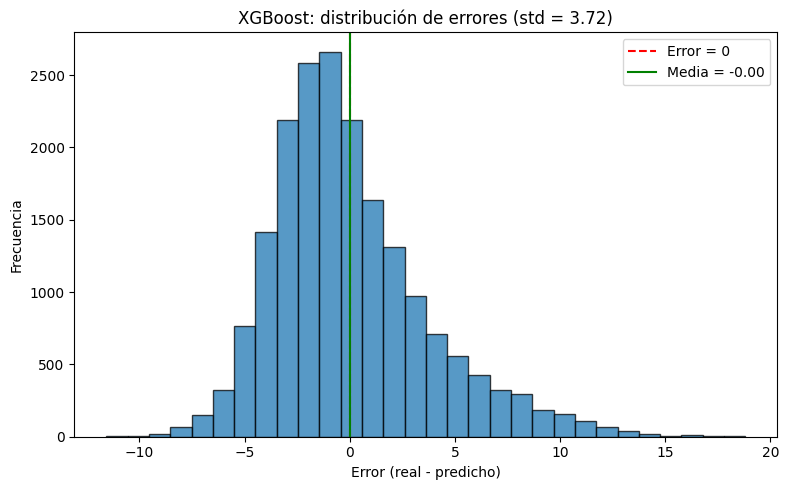

In [250]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import check_cv

X_arr = np.asarray(X)
y_arr = np.ravel(Y)
cv_obj = check_cv(cv, y_arr, classifier=False)   # funciona aunque cv sea un entero

errores = []
for idx_train, idx_test in cv_obj.split(X_arr, y_arr):
    modelo = clone(model_xgb).fit(X_arr[idx_train], y_arr[idx_train])
    pred = modelo.predict(X_arr[idx_test])
    errores.extend(y_arr[idx_test] - pred)       # error = real - predicho

errores = np.array(errores)

plt.figure(figsize=(8, 5))
plt.hist(errores, bins=30, edgecolor="black", alpha=0.75)
plt.axvline(0, color="red", linestyle="--", label="Error = 0")
plt.axvline(errores.mean(), color="green", label=f"Media = {errores.mean():.2f}")
plt.title(f"XGBoost: distribución de errores (std = {errores.std():.2f})")
plt.xlabel("Error (real - predicho)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

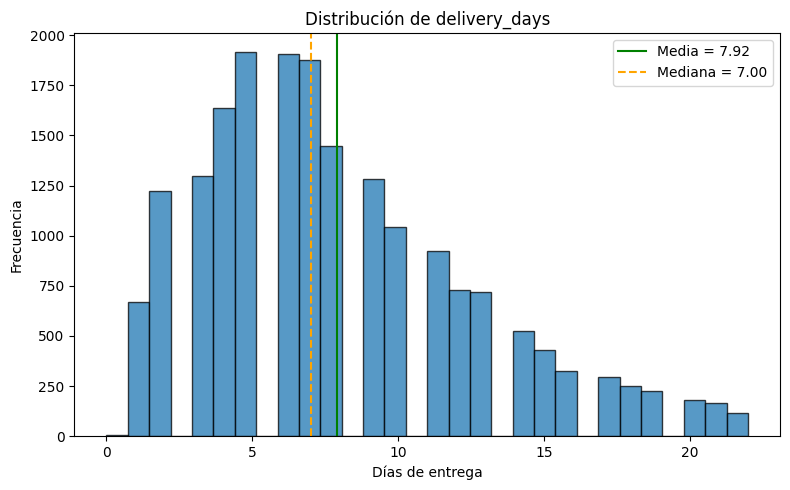

In [252]:
import matplotlib.pyplot as plt

col = "delivery_days"   # cambia por el nombre exacto de tu columna
datos = df[col].dropna()

plt.figure(figsize=(8, 5))
plt.hist(datos, bins=30, edgecolor="black", alpha=0.75)
plt.axvline(datos.mean(), color="green", label=f"Media = {datos.mean():.2f}")
plt.axvline(datos.median(), color="orange", linestyle="--", label=f"Mediana = {datos.median():.2f}")
plt.title(f"Distribución de {col}")
plt.xlabel("Días de entrega")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

=== % de pedidos que llegan a más tardar en (predicho + margen) ===
Margen  0.00 días ->  58.29%
Margen  1.00 días ->  68.29%
Margen  2.00 días ->  75.86%
Margen  3.00 días ->  81.99%
Margen  3.72 días ->  85.30%
Margen  5.00 días ->  89.74%
Margen  7.00 días ->  94.32%
Margen 10.00 días ->  98.18%

=== Margen necesario para una cobertura objetivo ===
80% de los pedidos llegan a más tardar en predicho + 2.63 días (redondeado: +3)
90% de los pedidos llegan a más tardar en predicho + 5.08 días (redondeado: +6)
95% de los pedidos llegan a más tardar en predicho + 7.43 días (redondeado: +8)
99% de los pedidos llegan a más tardar en predicho + 11.26 días (redondeado: +12)


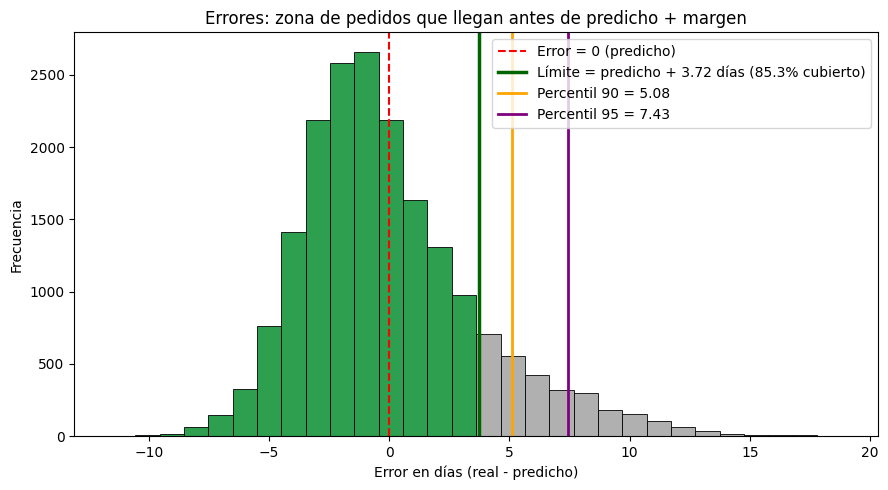

In [261]:
import numpy as np
import matplotlib.pyplot as plt

sigma = errores.std()

# 1) Cobertura con márgenes fijos: % de pedidos que llegan a más tardar en predicho + margen
print("=== % de pedidos que llegan a más tardar en (predicho + margen) ===")
for m in [0, 1, 2, 3, sigma, 5, 7, 10]:
    print(f"Margen {m:5.2f} días -> {np.mean(errores <= m) * 100:6.2f}%")

# 2) Margen necesario para alcanzar una cobertura objetivo
print("\n=== Margen necesario para una cobertura objetivo ===")
for p in [80, 90, 95, 99]:
    m = np.percentile(errores, p)
    print(f"{p}% de los pedidos llegan a más tardar en predicho + {m:.2f} días "
          f"(redondeado: +{int(np.ceil(m))})")
# 3) Gráfico: histograma de errores resaltando la zona cubierta
p90 = np.percentile(errores, 90)
p95 = np.percentile(errores, 95)
limite = sigma          # cambia a p90 o p95 para resaltar otra cobertura
cobertura = np.mean(errores <= limite) * 100

fig, ax = plt.subplots(figsize=(9, 5))

# Histograma calculado a mano para poder colorear cada barra
conteos, bordes = np.histogram(errores, bins=30)
centros = (bordes[:-1] + bordes[1:]) / 2
anchos = np.diff(bordes)
colores = np.where(bordes[1:] <= limite, "#2e9e4f", "#b0b0b0")   # verde = cubierto, gris = fuera

ax.bar(centros, conteos, width=anchos, color=colores, edgecolor="black", linewidth=0.6)

# Líneas de referencia
ax.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Error = 0 (predicho)")
ax.axvline(limite, color="darkgreen", linewidth=2.5,
           label=f"Límite = predicho + {limite:.2f} días ({cobertura:.1f}% cubierto)")
ax.axvline(p90, color="orange", linewidth=2, label=f"Percentil 90 = {p90:.2f}")
ax.axvline(p95, color="purple", linewidth=2, label=f"Percentil 95 = {p95:.2f}")

ax.set_title("Errores: zona de pedidos que llegan antes de predicho + margen")
ax.set_xlabel("Error en días (real - predicho)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

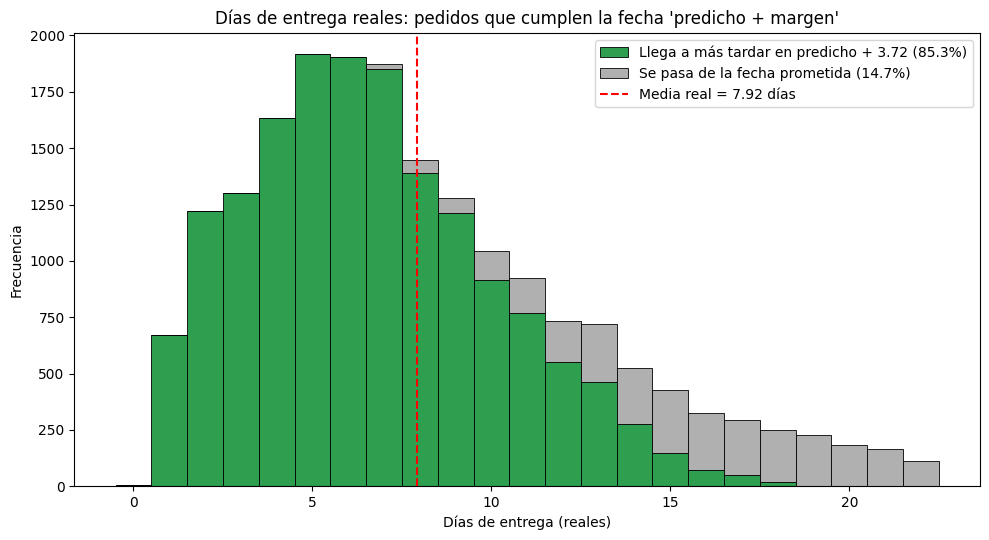

Cobertura por rango de días de entrega reales:
    0.0 a   4.0 días -> 100.0% cubierto
    4.0 a   7.0 días ->  99.7% cubierto
    7.0 a  11.0 días ->  93.4% cubierto
   11.0 a  22.0 días ->  48.0% cubierto


In [264]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict

# 1) Predicciones out-of-fold alineadas con cada fila de Y
y_real = np.ravel(Y)
y_pred = np.ravel(cross_val_predict(model_xgb, X, Y, cv=cv))
err = y_real - y_pred

# 2) Margen elegido (cambia a p90 o p95 si quieres otra cobertura)
p90 = np.percentile(err, 90)
p95 = np.percentile(err, 95)
margen = err.std()            # o p90 / p95

fecha_prometida = y_pred + margen
cubierto = y_real <= fecha_prometida
cobertura = cubierto.mean() * 100

# 3) Histograma de días de entrega REALES, apilado por cubierto / no cubierto
bins = np.arange(np.floor(y_real.min()) - 0.5, np.ceil(y_real.max()) + 1.5, 1)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist([y_real[cubierto], y_real[~cubierto]], bins=bins, stacked=True,
        color=["#2e9e4f", "#b0b0b0"], edgecolor="black", linewidth=0.6,
        label=[f"Llega a más tardar en predicho + {margen:.2f} ({cobertura:.1f}%)",
               f"Se pasa de la fecha prometida ({100 - cobertura:.1f}%)"])

ax.axvline(y_real.mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Media real = {y_real.mean():.2f} días")
ax.set_title("Días de entrega reales: pedidos que cumplen la fecha 'predicho + margen'")
ax.set_xlabel("Días de entrega (reales)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

# 4) Cobertura por rango de días reales
print("Cobertura por rango de días de entrega reales:")
cortes = np.percentile(y_real, [0, 25, 50, 75, 100])
for i in range(4):
    m = (y_real >= cortes[i]) & (y_real <= cortes[i + 1])
    print(f"  {cortes[i]:5.1f} a {cortes[i+1]:5.1f} días -> {cubierto[m].mean()*100:5.1f}% cubierto")

In [263]:
print(np.sort(np.unique(y_real))[:30])   # valores distintos de días
print(np.mean(y_real == np.round(y_real)))   # fracción de valores enteros (1.0 = todos)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22.]
1.0


In [251]:
import numpy as np

sigma = errores.std()   # 3.58 en tu caso

# 1) Literal: real <= predicho + std  (error <= std)
pct_debajo = np.mean(errores <= sigma) * 100

# 2) Dentro de la banda: predicho - std <= real <= predicho + std  (|error| <= std)
pct_banda = np.mean(np.abs(errores) <= sigma) * 100

# Extra: la misma banda con 2 desviaciones
pct_banda_2 = np.mean(np.abs(errores) <= 2 * sigma) * 100

print(f"Desviación estándar del error: {sigma:.2f}")
print(f"Real <= predicho + 1 std        : {pct_debajo:.2f}%")
print(f"Real dentro de predicho ± 1 std : {pct_banda:.2f}%")
print(f"Real dentro de predicho ± 2 std : {pct_banda_2:.2f}%")

Desviación estándar del error: 3.72
Real <= predicho + 1 std        : 85.30%
Real dentro de predicho ± 1 std : 73.07%
Real dentro de predicho ± 2 std : 94.53%


In [ ]:
   from sklearn.pipeline import make_pipeline
   from sklearn.preprocessing import MinMaxScaler

   model_dt  = DecisionTreeRegressor(min_samples_leaf=9, random_state=42)
   model_knn = make_pipeline(MinMaxScaler(), KNeighborsRegressor(n_neighbors=5, n_jobs=-1))
   model_rn  = make_pipeline(MinMaxScaler(), MLPRegressor(hidden_layer_sizes=(40,10), learning_rate_init=0.01, max_iter=700, random_state=42))

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

model_dt = DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=9, random_state=42)

model_knn = make_pipeline(
    MinMaxScaler(),
    KNeighborsRegressor(n_neighbors=5, metric='euclidean', n_jobs=-1)
)

model_rn = make_pipeline(
    MinMaxScaler(),
    MLPRegressor(activation="relu", hidden_layer_sizes=(40,50),
                 learning_rate_init=0.01, max_iter=1000, random_state=42)
)

model_xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)

regresores = [('dt', model_dt), ('knn', model_knn), ('net', model_rn), ('f', model_xgb)] #('net', model_rn)

model_vot_simple = VotingRegressor(estimators=regresores)                       # "hard"
model_vot_pond   = VotingRegressor(estimators=regresores, weights=[0.1, 0.2, 0.3, 0.4])  # "soft"

resultados_vot = {}
for nombre, m in [("Votacion_simple", model_vot_simple), ("Votacion_ponderada", model_vot_pond)]:
    s = pd.DataFrame(cross_validate(m, X, Y, cv=cv, scoring=scoring, return_train_score=True))
    r = s.mean()
    cols = [c for c in r.index if c.startswith(("test_", "train_"))]
    r[cols] = r[cols].abs()
    resultados_vot[nombre] = r

print(pd.DataFrame(resultados_vot).T)

                    fit_time  score_time  test_neg_mean_absolute_error  \
Votacion_simple     6.041641    0.049425                      2.812779   
Votacion_ponderada  5.949907    0.050586                      2.792403   

                    train_neg_mean_absolute_error  \
Votacion_simple                          2.309833   
Votacion_ponderada                       2.429134   

                    test_neg_mean_squared_error  train_neg_mean_squared_error  \
Votacion_simple                       13.332588                      9.029409   
Votacion_ponderada                    13.106628                      9.919738   

                    test_neg_root_mean_squared_error  \
Votacion_simple                             3.651079   
Votacion_ponderada                          3.619969   

                    train_neg_root_mean_squared_error  test_neg_wmape  \
Votacion_simple                              3.004893        0.359012   
Votacion_ponderada                           3.149554     